In [1]:
import time
import h5py

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import scipy.stats as st

from chemrixs.average import Average
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
from pathlib import Path
from scipy.ndimage._filters import uniform_filter1d as uf
%matplotlib widget 

## Load and plot the data first to see how the data looks

In in the yaml file you need to change the 'TT_corr: {bool: True, offset: 1100}' bool to False if you haven't created the file with TT correction yet

/sdf/home/a/amke/DataAcceleratorChemRIXS/src/chemrixs/utils.py:398: RuntimeWarning: invalid value encountered in divide
  avg[key] = avg[key]/counts_off[:,np.newaxis]
/sdf/home/a/amke/DataAcceleratorChemRIXS/src/chemrixs/utils.py:393: RuntimeWarning: invalid value encountered in divide
  avg[key] = avg[key]/counts_on[:,np.newaxis]
/sdf/home/a/amke/DataAcceleratorChemRIXS/src/chemrixs/utils.py:396: RuntimeWarning: invalid value encountered in divide
  avg[key] = avg[key]/counts_off
/sdf/home/a/amke/DataAcceleratorChemRIXS/src/chemrixs/utils.py:391: RuntimeWarning: invalid value encountered in divide
  avg[key] = avg[key]/counts_on


saving data in ./avg/Run0074to0074.h5
dict_keys(['axis_svls_off_mean', 'axis_svls_off_std', 'axis_svls_off_sum', 'axis_svls_on_mean', 'axis_svls_on_std', 'axis_svls_on_sum', 'counts_off', 'counts_on', 'scanvar_off', 'scanvar_on', 'PFY_on_mean', 'PFY_on_std', 'PFY_off_mean', 'PFY_off_std', 'E_emi'])


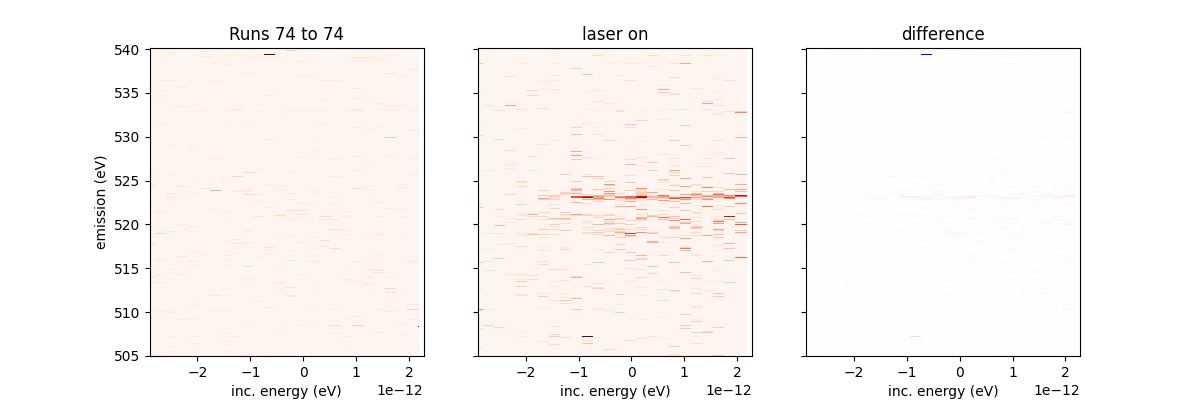

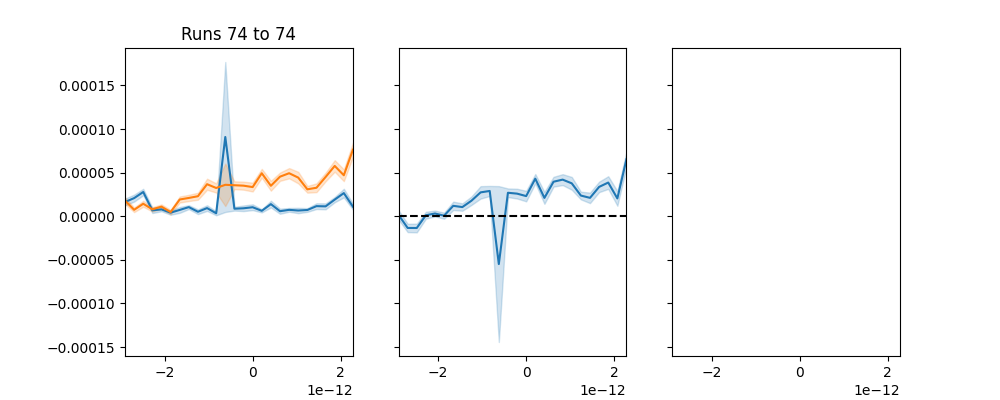

In [2]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'

bgrun = 61
# runs=[70,71,72,74,75,76,77,78,79,80,81,82,83] # O K-edge A peak time trace
# runs=[84,86,87,88,89,90,91,92,93,94,95,96,97,98,99,102,103,104] # O K-edge B peak time trace
runs=[74]#[166,167,168,169,170,171,172,173,174,175,176,177,178,180,181,182,183,184,187,188,189,190,191,192,193,195,196,197,198,199,200] # N K-edge B peak time trace

# runs = [200]

exp = 'rix101331225'


fyaml = '../roi_inputTT.yml'

bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
bgyaml = '../BGroi_input.yml'

avg = Average(runs, proc_path = 'proc/Run', avg = 'mean', output_path = f'avg/{runs[0]}_to_{runs[-1]}.h5',
             raw_path = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run' , bgpath = bgname, fyaml=fyaml, bgyaml=bgyaml, 
             save= False,norm = True)

avg.plot_svls2D(figsize=(12,4),savefig=False,scale=10)

avg.plot_svls1D(figsize=(10,4),savefig=False)

avg.save_avg()
# 

In [3]:
run = runs[0]

fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
fyaml = '../roi_inputTT.yml'
bgyaml = '../BGroi_input.yml'

data = SmallData(fname,fyaml)
# bg = SmallData(bgname, bgyaml)

## Loading the data to look at the piranha (TT) signal

In [4]:
proc = Reduced(fname,bgname,fyaml,bgyaml)

expected_count = st.mode(proc.data.integrating.axis_svls.count, keepdims=False)[0]
mask1 = (proc.data.integrating.axis_svls.eventcodes[:,proc.data.yaml['evc'][True]]/proc.data.integrating.axis_svls.count) >0.5

mask2= (proc.data.integrating.axis_svls.eventcodes[:,proc.data.yaml['evc'][True]]/expected_count)>0.5
# np.sum(mask1==mask2)
# proc.data.scantype

<KeysViewHDF5 ['lxt_ttc', 'step_value']>
74
setting up properties
dataset prop <functools.cached_property object at 0x7f5380e63550>
dataset prop <functools.cached_property object at 0x7f5380e11e90>
dataset prop <functools.cached_property object at 0x7f5388f45dd0>
dataset prop <functools.cached_property object at 0x7f5389e51f50>
dataset prop <functools.cached_property object at 0x7f5380d8c850>
dataset prop <functools.cached_property object at 0x7f5388f49d10>
dataset prop <functools.cached_property object at 0x7f5388eca990>
dataset prop <functools.cached_property object at 0x7f5380e37210>
delay shape (9829,)
61
setting up properties
dataset prop <functools.cached_property object at 0x7f5380e69090>
dataset prop <functools.cached_property object at 0x7f5380e6b0d0>
dataset prop <functools.cached_property object at 0x7f5380e6b050>
dataset prop <functools.cached_property object at 0x7f5380e69e90>
dataset prop <functools.cached_property object at 0x7f5380e6ad90>
dataset prop <functools.cached_

### Plotting how the nominal delays during the experiment

Just a sanity check

Text(0.5, 0, 'frame #')

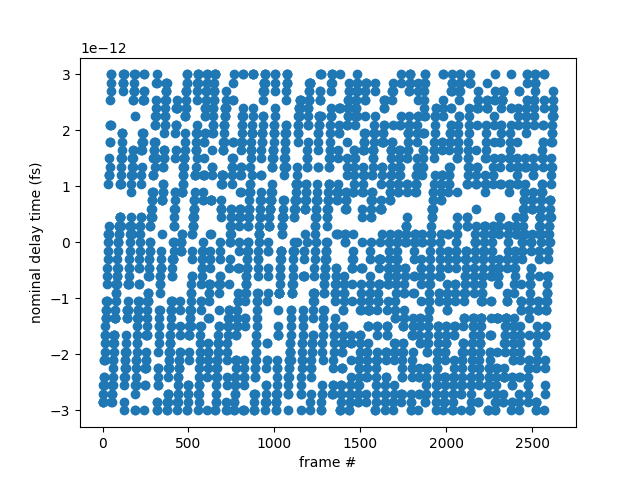

In [5]:
fig,ax=plt.subplots(1,1)
ax.scatter(np.arange(len(proc.data.integrating.axis_svls.delay[mask1])), proc.data.integrating.axis_svls.delay[mask1])
ax.set_ylabel('nominal delay time (fs)')
ax.set_xlabel('frame #')

## Load Piranha

- Loading the piranha data and creating masks for the on and off signal

- Plotting the averaged piranha signals

<KeysViewHDF5 ['lxt_ttc', 'step_value']>
74
setting up properties
dataset prop <functools.cached_property object at 0x7f53804a8590>
dataset prop <functools.cached_property object at 0x7f5388f1c590>
dataset prop <functools.cached_property object at 0x7f5380e62350>
dataset prop <functools.cached_property object at 0x7f53804b21d0>
dataset prop <functools.cached_property object at 0x7f5380472810>
dataset prop <functools.cached_property object at 0x7f53804fd290>
dataset prop <functools.cached_property object at 0x7f5388f3cf10>
dataset prop <functools.cached_property object at 0x7f53804ff010>
delay shape (9829,)


(0.0, 2000.0)

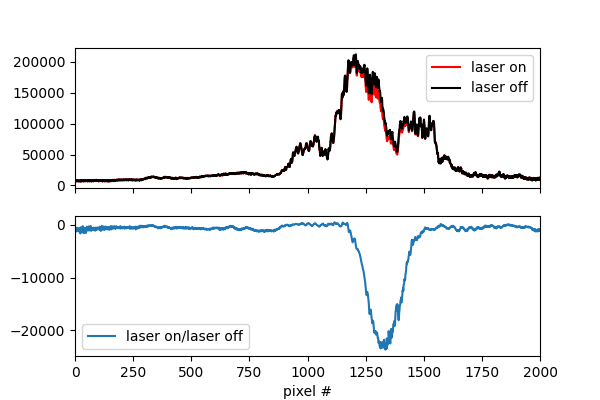

In [6]:

expected_count = st.mode(proc.data.integrating.axis_svls.count, keepdims=False)[0]

data.integrating.axis_svls.piranha.shape
mask_on = ((proc.data.integrating.axis_svls.eventcodes[:,proc.data.yaml['evc'][True]]/proc.data.integrating.axis_svls.count) >0.5).squeeze()# (data.integrating.axis_svls.eventcodes[:,272]==1)# np.asarray([data.integrating.axis_svls.eventcodes[:,data.yaml['evc'][True]]/expected_count>0.5]).squeeze()
mask_off = ((proc.data.integrating.axis_svls.eventcodes[:,proc.data.yaml['evc'][False]]/proc.data.integrating.axis_svls.count) >0.5).squeeze() #(data.integrating.axis_svls.eventcodes[:,273]==1)#

piranha = (proc.data.integrating.axis_svls.piranha)
piranha_on = (proc.data.integrating.axis_svls.piranha[mask_on,:])
piranha_off =(proc.data.integrating.axis_svls.piranha[mask_off,:])

fig,ax=plt.subplots(2,1,figsize=(6,4),sharex=True)
ax[0].plot(np.nanmean(piranha_on,axis=0).T, 'r',label='laser on')
ax[0].plot(np.nanmean(piranha_off,axis=0).T, 'k',label='laser off')
ax[0].legend()
# ax[1].plot((np.nanmean(piranha_on,axis=0))-(np.mean(piranha_off,axis=0)),label='laser on-laser off')
ax[1].plot(((np.nanmean(piranha_on,axis=0))/(np.mean(piranha_off,axis=0))-1)*2e5,label='laser on/laser off')
ax[1].legend()
ax[1].set_xlabel('pixel #')
ax[1].set_xlim(0,2000)

- plot individual piranha traces: it becomes visible how much the signal intensity fluctuates, we will deal with some background subtraction below to deal with this

Text(0.5, 0, 'pixel #')

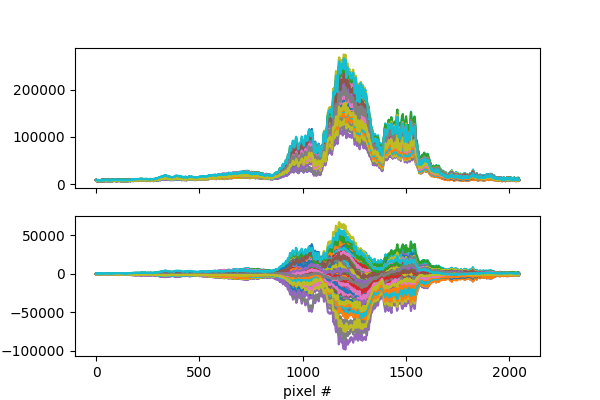

In [7]:
fig,ax=plt.subplots(2,1,figsize=(6,4),sharex=True)
ax[0].plot((piranha_on).T[:,:100],label='laser on')
# ax[0].plot(np.nanmean(piranha_off,axis=0).T, 'k',label='laser off')
ax[1].plot(((piranha_on.T[:,:100]))-(np.mean(piranha_off,axis=0))[:,np.newaxis],label='laser on-laser off')
ax[1].set_xlabel('pixel #')


### Do SVD

- Use the plot above of the averaged data of laser on/laser off to determine the ROI (range where the peak is located), the analysis is very sensitive to the ROI, so you may need to play around with it

-  we do the decomposition with a subset of the dark data (N is number of traces), using a larger N will slow down the code quite significantly and I have not seen a visible improvement for the data 

- the last line then does the background subtraction based on the background decomposition, you can choose the number of components (neigs) to use. the analysis below is based on 'traces'

In [8]:
max_p = -1
ROI=[1100,1600]
N = 2000

v, s = decomp_((piranha_off[:,:])[:,:],N) #decomposition of BG data (dark)
traces = decomp_1d(v,s,piranha[:,:],ROI,neigs=2) #all data only ROI

Now we are plotting the cleaned up piranha traces, you should see a strong negative signal



When we start seeing detector damages, instead of a somewhat Gaussian shape, you will see areas where it looks like something got simply got cut out of the Gaussian

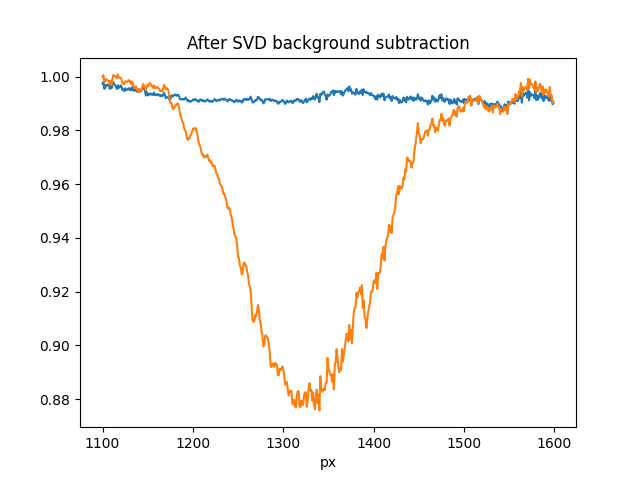

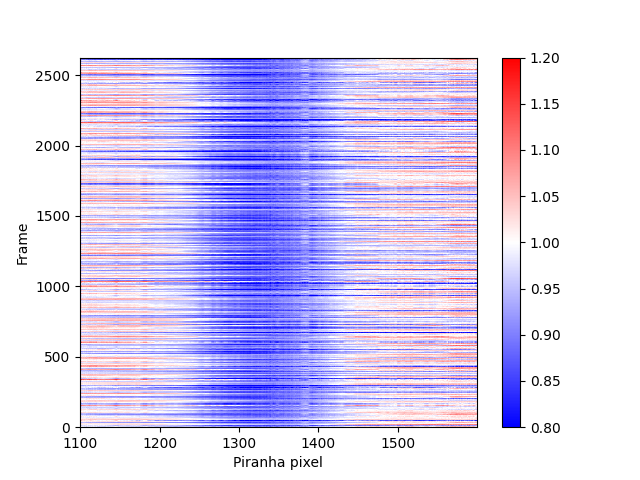

In [9]:



px = np.arange(ROI[0],ROI[1])
plt.figure()
plt.plot(px,np.nanmean(traces[mask_off[:],:],axis =0),label = 'Background')
plt.plot(px,np.nanmean(traces[mask_on[:],:],axis =0),label = 'Signal')
plt.title('After SVD background subtraction')
plt.xlabel('px')
plt.show()
plt.figure()
shots = np.arange(len(traces[mask_on[:]]))
plt.pcolormesh(px,np.arange(traces[mask_on[:]].shape[0]),traces[mask_on[:]],cmap = 'bwr',vmin = 0.8,vmax = 1.2)
plt.xlabel('Piranha pixel')
plt.ylabel('Frame')
plt.colorbar()
plt.show()



This was just a test to see if it would be easier to look at the differential for finding the edge, the fitting analysis below seems to be more robust

In [10]:


# ds=uf(np.diff(uf(traces[mask_on[:]],size=1,axis=1,mode='nearest'),axis=1),size=10,axis=1,mode='nearest')
# ds.shape

# px = np.arange(ROI[0],ROI[1])
# plt.figure()
# # plt.plot(px,np.nanmean(traces[mask_off[:2000],:],axis =0),label = 'Background')
# plt.plot(ds[100:200,:].T,label = 'Signal')
# plt.title('After SVD background subtraction')
# plt.xlabel('px')
# plt.show()
# plt.figure()
# shots = np.arange(len(ds))
# plt.pcolormesh(ds,cmap = 'bwr',vmin=-0.01,vmax=0.01)
# plt.xlabel('Piranha pixel')
# plt.ylabel('Shot')
# plt.colorbar()
# plt.show()

In [11]:
def find_edge(y):
    x = np.arange(len(y))
    slopes = np.diff(y)/np.diff(x)
    try:
        p,cov = fit_LS(asymmetric_gaussian,x,y,[1.,x[y==y.max()][0],20,60,7e-5,1e-3])
    except:
        print('FIT FAILED :(') 
        return -9999.0,-9999.0,-9999.0, slopes
    yfit = asymmetric_gaussian(x,*p[:,0])
    slopesfit = np.diff(yfit)/np.diff(x)
    idx = np.where(slopes==slopes.max())[0][0]
    idxfit = np.where(slopesfit==slopesfit.max())[0][0]
    amp = slopesfit[idxfit]
    fwhm = find_fwhm(slopesfit)
    return idxfit,amp,fwhm, slopesfit

In [12]:
def fit_gaussian_fast_linear(x, y, lb, ub):
    tmp = gaussian_moments_linear(x, y)
    p0 = [tmp[0],tmp[1],tmp[2]/2,tmp[2],tmp[3],tmp[4]]
    bounds = [lb, ub]

    if np.any(np.isnan(p0[:3])):
        return p0

    try:
        p0 = np.asarray(p0)
        p0[p0 < lb] = lb[p0 < lb]
        p0[p0 > ub] = ub[p0 > ub]

        popt, _ = curve_fit(
            # gaussian_linear,
            asymmetric_gaussian, #(x, A, mu, sigma1, sigma2,C,D)
            x,
            y,
            p0=p0,
            bounds=bounds,
            maxfev=3000
        )
        return popt
    except RuntimeError:
        return p0

def asymmetric_gaussian(x, A, mu, sigma1, sigma2,C,D):
    return np.where(x < mu,
                    A * np.exp(-((x - mu)**2) / (2 * sigma1**2)),
                    A * np.exp(-((x - mu)**2) / (2 * sigma2**2)))+D*x+C

## Fit Gaussian

Now the magic happens: I use the functions defined above to fit a Gaussian to the individual traces

- IMPORTANT: updated the input upper and lower bounds (ub and lb) according to how the traces look for your run

- when fitting: we first determine the Gaussian moment and then use that as input parameters for the fit. If the Gaussian moment parameters are outside the boundaries, they are set to the closer upper or lower bound

- We fit an asymmetric Gaussian, the 'lower side' sigma is then subtracted from the x0 to determine the edge position

In [13]:

px = np.arange(ROI[0],ROI[1])
x = px
spectra = -traces[mask_on[:]]
# spectra = np.zeros([10,traces.shape[1]])
# for i in np.arange(10):
#     spectra[i,:] = np.mean(2-traces[mask_on[:2000]][i*100:(i+1)*100,:],axis=0)

spectra.shape == (traces[mask_on[:]].shape[0], traces[mask_on[:]].shape[1])
x.shape == (traces[mask_on[:]].shape[0],)
params = np.array([
    gaussian_moments_linear(x, spectra[i])
    for i in range(spectra.shape[0])
])
lb = np.array([0., 1100,  1, 1,   -1.2, -1])  # A, mu, sigma, C (lower)
ub = np.array([1, 1300, 150, 200, -0.8, 1])    
params_fit = np.array([
    fit_gaussian_fast_linear(x, spectra[i],lb,ub)
    for i in range(spectra.shape[0])
])



A     = params[:, 0]
mu    = params[:, 1]
sigma = params[:, 2]
sigma1 = params[:, 2]
A_fit     = params_fit[:, 0]
mu_fit    = params_fit[:, 1]
sigma_fit = params_fit[:, 2]
sigma_fit1 = params_fit[:, 3]


'''
This is an alternative way to determine the edge from the max of the differential - does not make a difference, so I go with a simple mu-sigma, easier calculation
leading_edge_max  = np.array([
                                x[np.argmax(np.diff(asymmetric_gaussian(x, params[i,0], params[i,1], params[i,2], params[i,2], params[i,3], params[i,4]))/np.diff(x))]
                                for i in np.arange(params.shape[0])
                                ])#mu - sigma
leading_edge_fit_max  = np.array([
                                x[np.argmax(np.diff(asymmetric_gaussian(x, *params_fit[i,:]))/np.diff(x))] 
                                for i in np.arange(params_fit.shape[0])
                                ])#mu - sigma

'''
leading_edge  = mu - sigma
leading_edge_fit  = mu_fit - sigma_fit


Plot a 2D maps of the input traces and compare them to the ones reconstructed fit (middle), and from Gaussian moment (right).

If the fit does not look like the data at all, go back to the previous cell and update the lower and upper bounds

Text(0, 0.5, 'frame (#)')

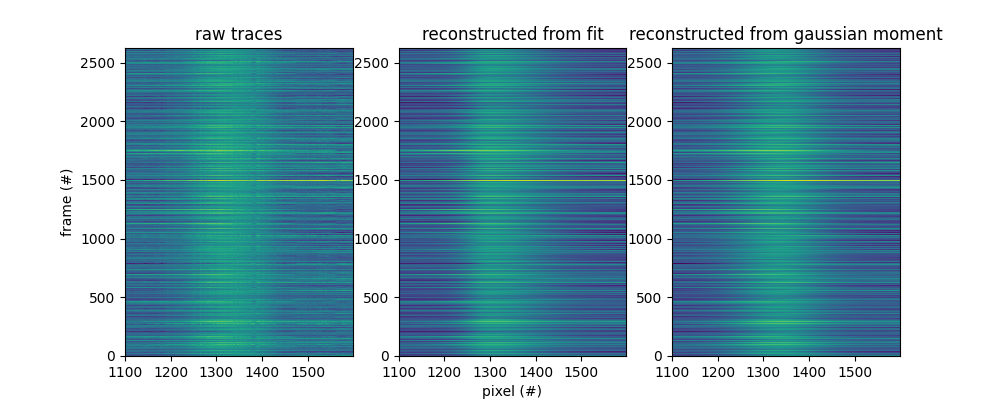

In [14]:
fit = np.array([
    asymmetric_gaussian(x, *params_fit[i,:])
    for i in range(spectra.shape[0])
])

fit_moment = np.array([
    asymmetric_gaussian(x, params[i,0], params[i,1], params[i,2], params[i,2], params[i,3], params[i,4])
    for i in range(spectra.shape[0])
])

fig,ax=plt.subplots(1,3,figsize=(10,4))
ax[0].pcolor(px, np.arange(spectra.shape[0]),spectra)
ax[0].set_title('raw traces')
ax[1].pcolor(px, np.arange(spectra.shape[0]),fit)
ax[1].set_title('reconstructed from fit')
ax[2].pcolor(px, np.arange(spectra.shape[0]),fit_moment)
ax[2].set_title('reconstructed from gaussian moment')

ax[1].set_xlabel('pixel (#)')
ax[0].set_ylabel('frame (#)')

Let's look at the distribution of edge positions - there's a lot of commented out lines, uncomment them if you want to compare the edge positions from different way of determining them, the label should tell you what they stand for

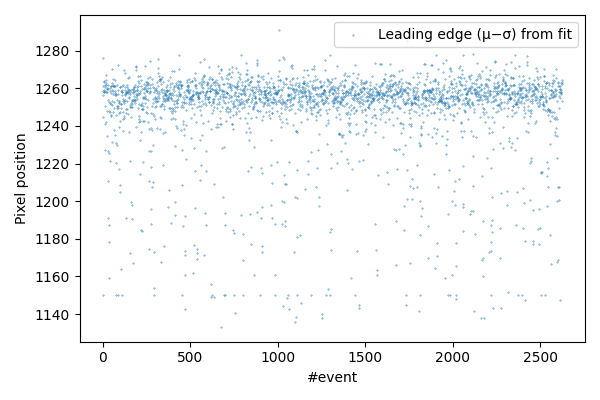

In [15]:


idx = np.arange(len(leading_edge))  # curve index, delay index, shot index, etc.

plt.figure(figsize=(6,4))
# plt.scatter(idx, leading_edge, s=.5, label="Leading edge (μ−σ) from gaussian mode")
plt.scatter(idx, leading_edge_fit, s=.1, label="Leading edge (μ−σ) from fit")
# plt.scatter(idx, leading_edge_max, s=.1, label="Leading edge (μ−σ) from max diff gaussian mode")
# plt.scatter(idx, leading_edge_fit_max, s=.1, label="Leading edge (μ−σ) from max diff fit")
# plt.plot(idx, leading_edge_fit-leading_edge, label="difference leading edge ")
# plt.scatter(idx, trailing_edge, s=5, label="Trailing edge (μ+σ)")
plt.xlabel("#event")
plt.ylabel("Pixel position")
plt.legend()
plt.tight_layout()
plt.show()

## Define ROI and save

From the scatter plot above determine the ROI and determine the low and high of the ROI, everything outside of that range will be set to the mean of the points inside the ROI

POSSIBLE IMPROVEMENT: instead of just using the mean, we coudl implement a nearest neighbour interpolation here


The results here will be saved to a txt file that will then be loaded when binning the data in 'process.py' to correct the nominal timing

In some cases with a very damaged target, the Gaussian moment seems to give a better estimate of the edge position than the fit, int that case set 'usefit' to False

In [ ]:

# np.savetxt(f"proc/leading_edge1{run}.txt", leading_edge)
low = 1200
high =1280
usefit = True # if true use fit, if false use Gaussian moment

if usefit:
    mean = np.nanmean(leading_edge_fit[np.logical_and(leading_edge_fit<high,leading_edge_fit>low)])
    leading_edge_fit[leading_edge_fit>high]=mean
    leading_edge_fit[leading_edge_fit<low]=mean
    np.savetxt(f"proc/leading_edge_{run}.txt", leading_edge_fit)
else:
    mean = np.nanmean(leading_edge[np.logical_and(leading_edge<high,leading_edge>low)])
    leading_edge[leading_edge>high]=mean
    leading_edge[leading_edge<low]=mean
    np.savetxt(f"proc/leading_edge_{run}.txt", leading_edge)



## Check if the edge position correlates with the nominal delay

Fortunately it doesn't seem to be the case, some weirdness at t=0

Text(0, 0.5, 'edge position')

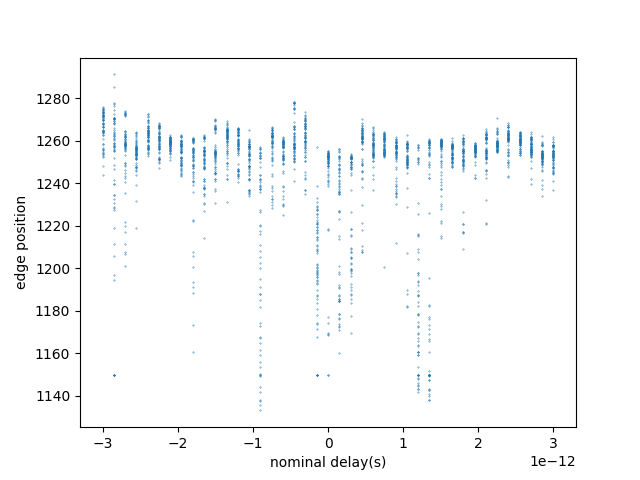

In [16]:
fig,ax=plt.subplots(1,1)
ax.scatter(data.integrating.axis_svls.delay[:][mask_on[:]],leading_edge_fit,s=0.1)
ax.set_xlabel('nominal delay(s)')
ax.set_ylabel('edge position')

Plot some of the traces together with fit (dashed line) and Gaussian moment (solid line)

Scatter x and dot mark the position of leading edge determined with Gaussian moment and fit, respectively

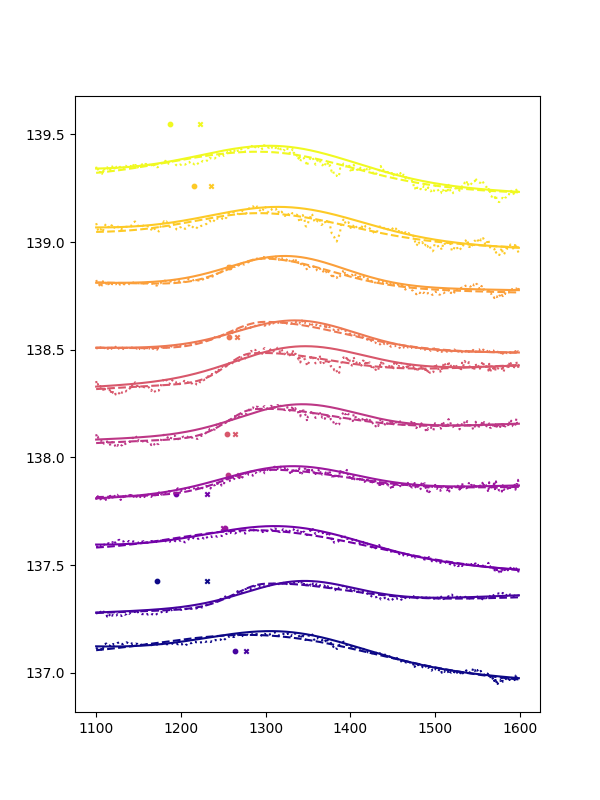

In [20]:
fig,ax =plt.subplots(1,1,figsize=(6,8))



cmap = mpl.colormaps['plasma']
colors = cmap(np.linspace(0, 1, len(np.arange(580,590,1))))


f=2
c=0
for i in np.arange(580,590,1):
    ax.plot(px,asymmetric_gaussian(px,params[i,0], params[i,1], params[i,2], params[i,2], params[i,3], params[i,4])+params[0,0]*i*f,color=colors[c])
    ax.plot(px,asymmetric_gaussian(px,*params_fit[i,:])+params[0,0]*i*f,'--',color=colors[c])
    ax.plot(px,spectra[i]+params[0,0]*i*f,':',color=colors[c])
    ax.scatter(leading_edge[i],params[0,0]*i*f+params[i,-2],s=10,marker='x',color=colors[c])
    ax.scatter(leading_edge_fit[i],params[0,0]*i*f+params[i,-2],s=10,marker='o',color=colors[c])
    c=c+1